In [1]:
import h5py

file_path = r"Dataset/archive/GOLD_XYZ_OSC.0001_1024.hdf5"

with h5py.File(file_path, "r") as f:
    print("Keys:")
    for key in f.keys():
        print(key)

Keys:
X
Y
Z


In [2]:
with h5py.File(file_path, "r") as f:
    for key in f.keys():
        print(key, f[key].shape)

X (2555904, 1024, 2)
Y (2555904, 24)
Z (2555904, 1)


In [3]:
import h5py
import numpy as np



with h5py.File(file_path, "r") as f:
    X = f["X"]
    Y = f["Y"]
    Z = f["Z"]

    print("X shape:", X.shape)
    print("Y shape:", Y.shape)
    print("Z shape:", Z.shape)

    print("\nFirst Y:")
    print(Y[0])

    print("\nFirst Z:")
    print(Z[0])

    print("\nX[0] shape:")
    print(X[0].shape)

    print("\nFirst 5 IQ samples:")
    print(X[0][:120])

X shape: (2555904, 1024, 2)
Y shape: (2555904, 24)
Z shape: (2555904, 1)

First Y:
[1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

First Z:
[-20]

X[0] shape:
(1024, 2)

First 5 IQ samples:
[[ 4.20273952e-02  2.34763235e-01]
 [-2.72882611e-01  4.05134916e-01]
 [-2.67072618e-01  2.27498889e-01]
 [-3.14850867e-01 -1.76458597e-01]
 [ 9.63341236e-01 -1.02571023e+00]
 [ 1.87244624e-01  6.44536376e-01]
 [ 2.60705411e-01 -4.00602192e-01]
 [-1.38889417e-01  3.37220818e-01]
 [ 3.51226389e-01 -3.00818056e-01]
 [ 6.83884501e-01 -1.90601695e+00]
 [ 1.19307786e-01  7.23491237e-02]
 [-1.77766070e-01 -3.49935830e-01]
 [ 4.21254300e-02 -2.73146898e-01]
 [ 1.16819859e+00  1.35799253e+00]
 [ 1.13426137e+00  4.34401125e-01]
 [ 3.39727253e-02 -9.00930226e-01]
 [ 1.82389474e+00 -1.91117674e-01]
 [ 1.11155123e-01  3.19545120e-01]
 [ 8.38508904e-01  3.62890035e-01]
 [ 1.07418180e+00  3.98637831e-01]
 [ 3.25316995e-01 -5.00284135e-01]
 [-7.12064922e-01 -2.04506859e-01]
 [-5.76841295e-01  1.49948746e-01]
 [

In [4]:
f= h5py.File(file_path , "r")

In [5]:
X

<Closed HDF5 dataset>

In [6]:
import h5py

f = h5py.File("Dataset/archive/GOLD_XYZ_OSC.0001_1024.hdf5", "r")
x = f["X"]
print(x[0].shape)

(1024, 2)


In [7]:
y= f["Y"]
z=f["Z"]
labels = np.argmax(y , axis = 1)

In [8]:
print("Class IDs:", np.unique(labels))

Class IDs: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]


In [9]:
import json
with open(r"Dataset/archive/classes-fixed.json" , "r") as f:
    classes = json.load(f)
print(classes)

['OOK', '4ASK', '8ASK', 'BPSK', 'QPSK', '8PSK', '16PSK', '32PSK', '16APSK', '32APSK', '64APSK', '128APSK', '16QAM', '32QAM', '64QAM', '128QAM', '256QAM', 'AM-SSB-WC', 'AM-SSB-SC', 'AM-DSB-WC', 'AM-DSB-SC', 'FM', 'GMSK', 'OQPSK']


In [10]:
sample = x[319488][0]
sample

array([-0.50679684,  0.4923161 ], dtype=float32)

In [11]:
sample[:10]

array([-0.50679684,  0.4923161 ], dtype=float32)

In [12]:
label = np.argmax(y[319488])
snr = z[319488][0]

In [13]:
print("Class ID:", label)
print("Modulation:", classes[label])
print("SNR:", snr, "dB")

Class ID: 3
Modulation: BPSK
SNR: -20 dB


In [14]:
for i in [0, 4096, 8192, 106496, 106498]:
    print(i, np.argmax(y[i]), z[i][0])

0 0 -20
4096 0 -18
8192 0 -16
106496 1 -20
106498 1 -20


Text(0, 0.5, 'Amplitude')

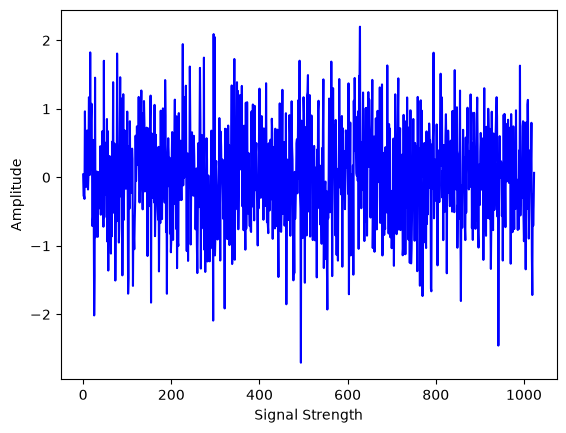

In [15]:
# Now I will plot te see how the signal works
import matplotlib.pyplot as plt
first = x[0]

plt.plot(first[: , 0] , color = "blue" )
plt.xlabel("Signal Strength")
plt.ylabel("Amplitude")

Text(0, 0.5, 'Amplitude')

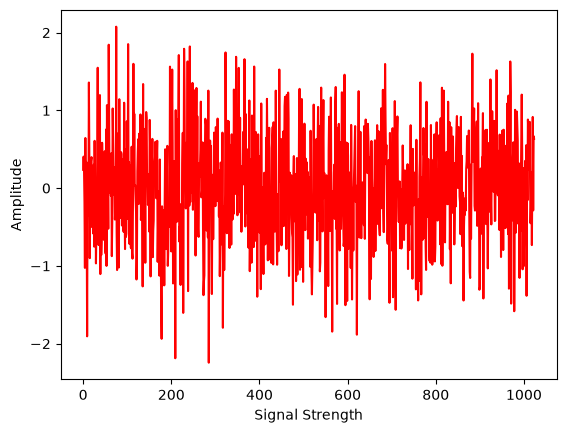

In [16]:
plt.plot( first[: ,1] , color = "red" )
plt.xlabel("Signal Strength")
plt.ylabel("Amplitude")

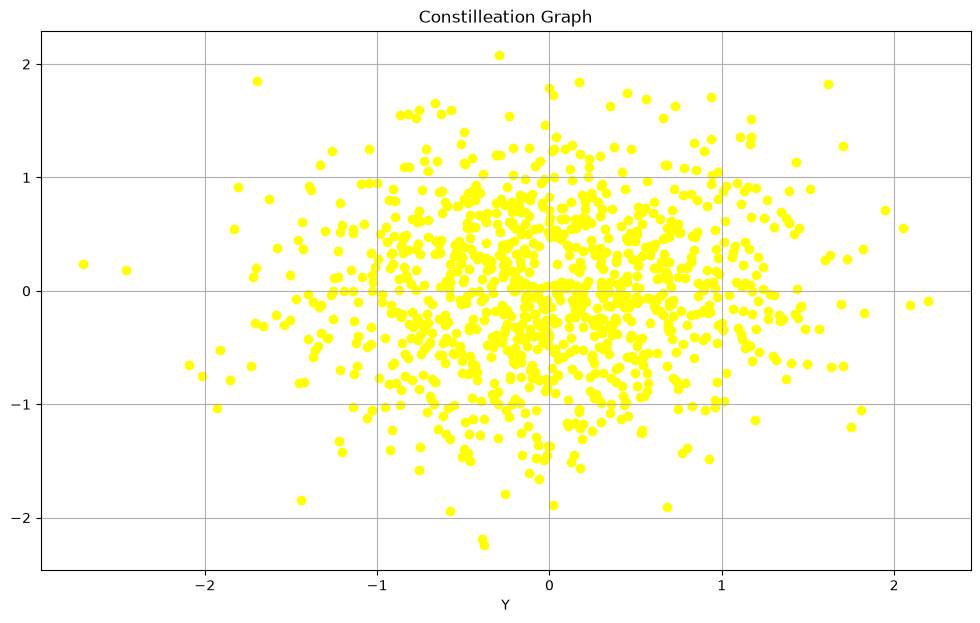

In [17]:
plt.figure(figsize=(12,7))
plt.scatter(first[: , 0] , first[: ,1] , color = "yellow" )

plt.xlabel("X")
plt.xlabel("Y")
plt.title("Constilleation Graph")

plt.grid()


In [18]:
for i in [0,100,189000,10000,969999]:
    label = np.argmax(y[i])
    snr = z[i][0]
    print(f"{i}-->{classes[label]} --> {snr}"
        
    )
    


0-->OOK --> -20
100-->OOK --> -20
189000-->4ASK --> 20
10000-->OOK --> -16
969999-->32APSK --> -16


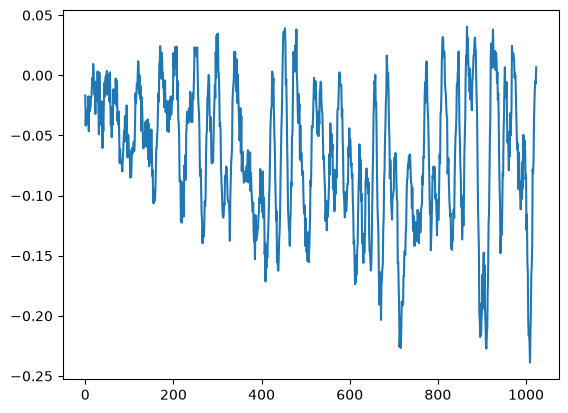

In [19]:
g = 189000
s1 = x[g]
i = s1[: , 0]
q=s1[: ,1]
plt.plot(i)

In [20]:
print(np.unique(z))

[-20 -18 -16 -14 -12 -10  -8  -6  -4  -2   0   2   4   6   8  10  12  14
  16  18  20  22  24  26  28  30]


In [21]:
for i in np.unique(z[:,0]):
    count = np.sum(z[:, 0] == i)
    print(f"{i} --> {count}")

-20 --> 98304
-18 --> 98304
-16 --> 98304
-14 --> 98304
-12 --> 98304
-10 --> 98304
-8 --> 98304
-6 --> 98304
-4 --> 98304
-2 --> 98304
0 --> 98304
2 --> 98304
4 --> 98304
6 --> 98304
8 --> 98304
10 --> 98304
12 --> 98304
14 --> 98304
16 --> 98304
18 --> 98304
20 --> 98304
22 --> 98304
24 --> 98304
26 --> 98304
28 --> 98304
30 --> 98304


In [22]:
for g in np.unique(labels):
    count = np.sum(labels == g)
    print(f"{classes[g]}--> {count}")

OOK--> 106496
4ASK--> 106496
8ASK--> 106496
BPSK--> 106496
QPSK--> 106496
8PSK--> 106496
16PSK--> 106496
32PSK--> 106496
16APSK--> 106496
32APSK--> 106496
64APSK--> 106496
128APSK--> 106496
16QAM--> 106496
32QAM--> 106496
64QAM--> 106496
128QAM--> 106496
256QAM--> 106496
AM-SSB-WC--> 106496
AM-SSB-SC--> 106496
AM-DSB-WC--> 106496
AM-DSB-SC--> 106496
FM--> 106496
GMSK--> 106496
OQPSK--> 106496


In [23]:
for i in range (0,500000 , 50000):
    label = np.argmax(y[i])
    print(label)

0
0
0
1
1
2
2
3
3
4


In [24]:
no=1096
label = np.argmax(y[no])
label
classes[label]

'OOK'

In [25]:
x[0]


array([[ 0.0420274 ,  0.23476323],
       [-0.2728826 ,  0.40513492],
       [-0.26707262,  0.22749889],
       ...,
       [-0.7055947 , -0.28693035],
       [-0.41157472,  0.66826206],
       [ 0.06487698,  0.6358149 ]], shape=(1024, 2), dtype=float32)

In [26]:
for i in range (0 , 100):
    for j in [0]:
        val = x[0][i][j]
        val1 = x[0][i][j+1]
        d = (val)**2 + (val)**2
        print(np.sqrt(d))
        
        

0.05943571
0.3859143
0.3776977
0.44526637
1.3623703
0.2648039
0.3686931
0.1964193
0.49670914
0.96715873
0.1687267
0.2513992
0.059574354
1.6520823
1.6040878
0.04804469
2.5793767
0.15719709
1.1858306
1.5191225
0.4600677
1.0070119
0.81577677
0.77156436
0.7150778
2.8514025
2.0310934
2.0572903
1.2367038
0.5590294
0.28267258
0.11899959
0.13456924
1.2297359
0.11079021
0.12262378
0.03480202
0.6383308
0.40940446
0.6425057
0.772211
0.020265548
0.2813293
0.2084861
0.9574126
0.31036985
1.0199449
2.4065344
0.8274865
0.06459589
0.030100146
0.71447784
0.3642017
0.3082762
1.2040268
1.328984
0.9536538
1.9247203
0.242059
0.75298667
0.4395975
0.20485796
0.8158514
1.5747147
0.3388151
1.2180427
0.7372664
0.3026245
1.9643414
0.35425064
0.7335391
0.69804406
0.0001913834
2.1310523
0.9066715
0.40986744
0.9062957
2.5556962
0.75518095
0.21314935
0.60826325
1.3463455
1.0311958
0.8055839
2.0663264
0.39280742
0.95077735
0.29445612
1.628492
2.0242887
0.09346916
1.7165192
0.8807573
0.11622352
0.96999675
0.08409884
0.

In [27]:
no_of_samples = 106496
samples_per_snr = 4096
sample_take = 150
X_list = []
Y_list = []
Z_list = []
for class_id in range (24):
    class_start = no_of_samples * class_id
    for snr_id in range (26):
        start = class_start + snr_id*samples_per_snr
        end = start + sample_take
        X_list.append(x[start:end])
        Y_list.append(y[start:end])
        Z_list.append(z[start:end])
X_subset = np.concatenate(X_list , axis=0)
Y_subset = np.concatenate(Y_list , axis=0)
Z_subset = np.concatenate(Z_list , axis=0)
        
        
    

In [28]:
print("X_subset:", X_subset.shape)
print("Y_subset:", Y_subset.shape)
print("Z_subset:", Z_subset.shape)

X_subset: (93600, 1024, 2)
Y_subset: (93600, 24)
Z_subset: (93600, 1)


In [29]:
Y_subset

array([[1, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 1],
       [0, 0, 0, ..., 0, 0, 1],
       [0, 0, 0, ..., 0, 0, 1]], shape=(93600, 24))

In [30]:
label1 = np.argmax(Y_subset , axis=1)


In [31]:
#  Amplitude for the extracted data 
I = X_subset[: , : ,0]
Q = X_subset[: , : ,1]
amplitude = np.sqrt(I**2+Q**2)
amplitude.shape

(93600, 1024)

In [32]:
import numpy as np
import pandas as pd

from scipy.stats import skew as scipy_skew
from scipy.stats import kurtosis as scipy_kurtosis
amp = np.sqrt(I**2 + Q**2)
phase = np.arctan2(Q, I)

# Unwrapped phase for instantaneous frequency
phase_unwrapped = np.unwrap(phase, axis=1)


# 2. Basic Amplitude Statistics
amp_mean = amp.mean(axis=1)
amp_std = amp.std(axis=1)
amp_max = amp.max(axis=1)
amp_min = amp.min(axis=1)
amp_ptp = amp_max - amp_min
amp_var = amp_std**2


# 3. Power & Ratios
power = np.mean(I**2 + Q**2, axis=1)

RMS_amp = np.sqrt(power)

crest_factor = amp_max / (RMS_amp + 1e-12)

papr = 10 * np.log10(
    (amp_max**2) / (power + 1e-12)
)


# 4. Instantaneous Frequency
inst_freq = np.diff(phase_unwrapped, axis=1)

inst_freq_mean = inst_freq.mean(axis=1)
inst_freq_std = inst_freq.std(axis=1)


# 5. Higher-Order Amplitude Moments

amp_mean_col = amp.mean(axis=1, keepdims=True)
amp_centered = amp - amp_mean_col

amp_skew = (
    np.mean(amp_centered**3, axis=1)
    / (amp_std**3 + 1e-12)
)

amp_kurtosis = (
    np.mean(amp_centered**4, axis=1)
    / (amp_std**4 + 1e-12)
    - 3
)


# 6. Scipy Skewness & Kurtosis
# Use aliases so they cannot conflict with variables named
# skew or kurtosis elsewhere in the notebook.

amp_kurt = scipy_kurtosis(amp, axis=1)

I_skew = scipy_skew(I, axis=1)
Q_skew = scipy_skew(Q, axis=1)


# 7. Feature Names
feature_names = [
    "I_mean",
    "I_std",
    "Q_mean",
    "Q_std",
    "amp_mean",
    "amp_std",
    "amp_max",
    "phase_mean",
    "phase_std",
    "power",
    "RMS_amp",
    "amp_var",
    "amp_skew",
    "amp_kurtosis",
    "amp_min",
    "amp_ptp",
    "amp_kurt",
    "I_skew",
    "Q_skew",
    "crest_factor",
    "papr",
    "inst_freq_mean",
    "inst_freq_std",
]


# 8. Stack Features
features = np.column_stack([
    I.mean(axis=1),
    I.std(axis=1),

    Q.mean(axis=1),
    Q.std(axis=1),

    amp_mean,
    amp_std,
    amp_max,

    phase.mean(axis=1),
    phase.std(axis=1),

    power,
    RMS_amp,
    amp_var,

    amp_skew,
    amp_kurtosis,

    amp_min,
    amp_ptp,
    amp_kurt,

    I_skew,
    Q_skew,

    crest_factor,
    papr,

    inst_freq_mean,
    inst_freq_std
])


# 9. Create DataFrame
df_features = pd.DataFrame(
    features,
    columns=feature_names
)




In [33]:
from sklearn.model_selection import train_test_split

X = df_features.values
y = np.asarray(label1).ravel()

x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train shape:", x_train.shape)
print("Test shape :", x_test.shape)
print("Number of classes:", len(np.unique(y)))

Train shape: (74880, 23)
Test shape : (18720, 23)
Number of classes: 24


In [34]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)

xg = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    num_class=len(np.unique(y)),
    eval_metric="mlogloss",
    n_jobs=-1,
    random_state=42
)

xg.fit(x_train, y_train)

xgb_pred = xg.predict(x_test)

print("XGBoost Results")
print("-" * 40)
print("Accuracy :", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred, average="macro"))
print("Recall   :", recall_score(y_test, xgb_pred, average="macro"))
print("F1       :", f1_score(y_test, xgb_pred, average="macro"))

XGBoost Results
----------------------------------------
Accuracy : 0.41623931623931626
Precision: 0.40367970027358585
Recall   : 0.41623931623931626
F1       : 0.4086224823218855


In [35]:
from sklearn.linear_model import LogisticRegression


In [36]:
from sklearn.neighbors import KNeighborsClassifier


In [37]:
lr = LogisticRegression(max_iter=2000,
    random_state=42)





In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print("Scaled training shape:", x_train_scaled.shape)
print("Scaled testing shape :", x_test_scaled.shape)

Scaled training shape: (74880, 23)
Scaled testing shape : (18720, 23)


In [39]:
lr.fit(x_train_scaled , y_train)
lr_pred =lr.predict(x_test_scaled)
print(accuracy_score(y_test , lr_pred))
print(f1_score(y_test , lr_pred , average="macro"))
print(precision_score(y_test , lr_pred , average="macro"))
print(recall_score(y_test , lr_pred , average="macro"))

0.36527777777777776
0.34267437697675357
0.3522895035047628
0.36527777777777776


In [40]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    n_jobs=-1,
    random_state=42
)

rf.fit(x_train, y_train)

rf_pred = rf.predict(x_test)

print("Random Forest Results")
print("-" * 40)
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred, average="macro"))
print("Recall   :", recall_score(y_test, rf_pred, average="macro"))
print("F1       :", f1_score(y_test, rf_pred, average="macro"))

Random Forest Results
----------------------------------------
Accuracy : 0.4096688034188034
Precision: 0.4079813169022055
Recall   : 0.4096688034188034
F1       : 0.40777789565002726


In [41]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(
    n_neighbors=23,
    weights="uniform",
    metric="euclidean",
    n_jobs=-1
)

knn.fit(x_train_scaled, y_train)

knn_pred = knn.predict(x_test_scaled)

print("KNN Results")
print("-" * 40)
print("Accuracy :", accuracy_score(y_test, knn_pred))
print("Precision:", precision_score(y_test, knn_pred, average="macro"))
print("Recall   :", recall_score(y_test, knn_pred, average="macro"))
print("F1       :", f1_score(y_test, knn_pred, average="macro"))

KNN Results
----------------------------------------
Accuracy : 0.31490384615384615
Precision: 0.3288760504729244
Recall   : 0.31490384615384615
F1       : 0.31881222197288955


In [42]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(
    n_estimators=300,
    learning_rate=0.1,
    random_state=42
)

ada.fit(x_train, y_train)

ada_pred = ada.predict(x_test)

print("AdaBoost Results")
print("-" * 40)
print("Accuracy :", accuracy_score(y_test, ada_pred))
print("Precision:", precision_score(y_test, ada_pred, average="macro"))
print("Recall   :", recall_score(y_test, ada_pred, average="macro"))
print("F1       :", f1_score(y_test, ada_pred, average="macro"))

AdaBoost Results
----------------------------------------
Accuracy : 0.15721153846153846
Precision: 0.159550042480023
Recall   : 0.15721153846153846
F1       : 0.10761190761404182


C:\Users\mishr\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [43]:
results = pd.DataFrame({
    "Model": [
        "XGBoost",
        "KNN",
        "Logistic Regression",
        "Random Forest",
        "AdaBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, xgb_pred),
        accuracy_score(y_test, knn_pred),
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, ada_pred)
    ],
    "Precision": [
        precision_score(y_test, xgb_pred, average="macro"),
        precision_score(y_test, knn_pred, average="macro"),
        precision_score(y_test, lr_pred, average="macro"),
        precision_score(y_test, rf_pred, average="macro"),
        precision_score(y_test, ada_pred, average="macro")
    ],
    "Recall": [
        recall_score(y_test, xgb_pred, average="macro"),
        recall_score(y_test, knn_pred, average="macro"),
        recall_score(y_test, lr_pred, average="macro"),
        recall_score(y_test, rf_pred, average="macro"),
        recall_score(y_test, ada_pred, average="macro")
    ],
    "F1": [
        f1_score(y_test, xgb_pred, average="macro"),
        f1_score(y_test, knn_pred, average="macro"),
        f1_score(y_test, lr_pred, average="macro"),
        f1_score(y_test, rf_pred, average="macro"),
        f1_score(y_test, ada_pred, average="macro")
    ]
})

results

C:\Users\mishr\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Model,Accuracy,Precision,Recall,F1
0,XGBoost,0.416239,0.403680,0.416239,0.408622
1,KNN,0.314904,0.328876,0.314904,0.318812
2,Logistic Regression,0.365278,0.352290,0.365278,0.342674
3,Random Forest,0.409669,0.407981,0.409669,0.407778
4,AdaBoost,0.157212,0.159550,0.157212,0.107612


In [44]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import numpy as np

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

PyTorch version: 2.11.0+cu128
CUDA available: True
Using device: cuda


In [45]:
# Original IQ data
X_raw = X_subset.astype(np.float32)
y_raw = np.asarray(label1).astype(np.int64)

print("Raw IQ shape:", X_raw.shape)
print("Labels shape:", y_raw.shape)

Raw IQ shape: (93600, 1024, 2)
Labels shape: (93600,)


## Phase 2 — Self-Supervised Contrastive Pretraining + Open-Set Detection

**Scope for this abstract:** RadioML 2018.01A only. Near-neighbor open-set split — `64QAM` held out entirely as "unknown," the rest of the QAM family (16/32/128/256QAM) plus all other classes stay "known." No labels are used during pretraining, only during the linear probe and for building known-class centroids.

Cross-domain (DroneRF/CardRF) is explicitly out of scope here — future work only.


In [46]:
# --- Load known/unknown split directly from the HDF5 file (fixes the X_raw/y_raw
#     length mismatch from cell 57 -- we no longer rely on the stale `label1` var) ---

import json
import numpy as np
import h5py

with open(r"Dataset/archive/classes-fixed.json", "r") as f:
    CLASS_NAMES = json.load(f)   # list of 24 modulation names, index = class_id

NUM_CLASSES = len(CLASS_NAMES)
SAMPLES_PER_CLASS = 106496   # fixed layout of RadioML 2018.01A
SNRS_PER_CLASS = 26
SAMPLES_PER_SNR = 4096

# --- near-neighbor open-set split ---
UNKNOWN_CLASS_NAMES = ["64QAM"]          # held out entirely -- never seen in pretraining or probing
KNOWN_CLASS_NAMES = [c for c in CLASS_NAMES if c not in UNKNOWN_CLASS_NAMES]

UNKNOWN_IDS = [CLASS_NAMES.index(c) for c in UNKNOWN_CLASS_NAMES]
KNOWN_IDS = [CLASS_NAMES.index(c) for c in KNOWN_CLASS_NAMES]

print(f"Known classes ({len(KNOWN_IDS)}):", KNOWN_CLASS_NAMES)
print(f"Unknown (held-out) classes ({len(UNKNOWN_IDS)}):", UNKNOWN_CLASS_NAMES)

# how many samples to pull per (class, SNR) bin -- bump this up later once the
# pipeline runs end to end; 300/bin keeps the first pass fast
SAMPLES_PER_BIN = 300

def load_class_block(f, class_id, samples_per_bin=SAMPLES_PER_BIN):
    """Load samples_per_bin examples from every SNR bin for one class_id.
    Returns (X: [n,1024,2] float32, snr: [n] int, label: [n] int)."""
    X_list, snr_list = [], []
    class_start = SAMPLES_PER_CLASS * class_id
    for snr_id in range(SNRS_PER_CLASS):
        start = class_start + snr_id * SAMPLES_PER_SNR
        end = start + samples_per_bin
        X_list.append(f["X"][start:end])
        snr_list.append(f["Z"][start:end, 0])
    X = np.concatenate(X_list, axis=0).astype(np.float32)
    snr = np.concatenate(snr_list, axis=0).astype(np.int64)
    label = np.full(len(X), class_id, dtype=np.int64)
    return X, snr, label

with h5py.File(file_path, "r") as f:
    known_X, known_snr, known_y = [], [], []
    for cid in KNOWN_IDS:
        Xc, snrc, yc = load_class_block(f, cid)
        known_X.append(Xc); known_snr.append(snrc); known_y.append(yc)
    known_X = np.concatenate(known_X, axis=0)
    known_snr = np.concatenate(known_snr, axis=0)
    known_y = np.concatenate(known_y, axis=0)

    unknown_X, unknown_snr, unknown_y = [], [], []
    for cid in UNKNOWN_IDS:
        Xc, snrc, yc = load_class_block(f, cid)
        unknown_X.append(Xc); unknown_snr.append(snrc); unknown_y.append(yc)
    unknown_X = np.concatenate(unknown_X, axis=0)
    unknown_snr = np.concatenate(unknown_snr, axis=0)
    unknown_y = np.concatenate(unknown_y, axis=0)

print("Known X:", known_X.shape, "| Unknown X:", unknown_X.shape)


Known classes (23): ['OOK', '4ASK', '8ASK', 'BPSK', 'QPSK', '8PSK', '16PSK', '32PSK', '16APSK', '32APSK', '64APSK', '128APSK', '16QAM', '32QAM', '128QAM', '256QAM', 'AM-SSB-WC', 'AM-SSB-SC', 'AM-DSB-WC', 'AM-DSB-SC', 'FM', 'GMSK', 'OQPSK']
Unknown (held-out) classes (1): ['64QAM']
Known X: (179400, 1024, 2) | Unknown X: (7800, 1024, 2)


In [47]:
# --- train/val/test split for known classes (stratified by class), plus a held-out
#     test split for the unknown class. Unknown data is NEVER used in pretraining
#     or in the linear probe -- only at open-set evaluation time. ---

from sklearn.model_selection import train_test_split

SEED = 42

k_train_idx, k_temp_idx = train_test_split(
    np.arange(len(known_X)), test_size=0.30, random_state=SEED, stratify=known_y
)
k_val_idx, k_test_idx = train_test_split(
    k_temp_idx, test_size=0.5, random_state=SEED, stratify=known_y[k_temp_idx]
)

X_train, y_train, snr_train = known_X[k_train_idx], known_y[k_train_idx], known_snr[k_train_idx]
X_val,   y_val,   snr_val   = known_X[k_val_idx],   known_y[k_val_idx],   known_snr[k_val_idx]
X_test,  y_test,  snr_test  = known_X[k_test_idx],  known_y[k_test_idx],  known_snr[k_test_idx]

# unknown data only used at test time
X_unk, y_unk, snr_unk = unknown_X, unknown_y, unknown_snr

print("Train:", X_train.shape, "Val:", X_val.shape, "Test (known):", X_test.shape, "Test (unknown):", X_unk.shape)


Train: (125580, 1024, 2) Val: (26910, 1024, 2) Test (known): (26910, 1024, 2) Test (unknown): (7800, 1024, 2)


In [48]:
# --- import dataset/model/augmentation code from iq_utils.py ---
# (moved out of notebook cells into a real .py file so DataLoader(num_workers>0)
#  works on Windows: worker processes need to `import` this cleanly, not
#  re-execute notebook cell state)
from iq_utils import (
    time_shift, phase_rotation, noise_injection, channel_distortion, augment,
    ContrastiveIQDataset, LabeledIQDataset, IQEncoder, ProjectionHead, nt_xent_loss
)
from torch.utils.data import DataLoader


In [50]:
from iq_utils import ContrastiveIQDataset, IQEncoder, ProjectionHead, nt_xent_loss
from torch.utils.data import DataLoader
import torch
import time

print("CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

# IMPORTANT: start with zero workers
contrastive_dataset = ContrastiveIQDataset(X_raw)

loader = DataLoader(
    contrastive_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,       # VERY IMPORTANT FOR NOW
    pin_memory=True
)

print("Dataset size:", len(contrastive_dataset))

# Test DataLoader only
t0 = time.time()

x1, x2 = next(iter(loader))

print("First batch loaded!")
print("x1:", x1.shape, x1.dtype)
print("x2:", x2.shape, x2.dtype)
print("Loading time:", time.time() - t0, "seconds")

CUDA: True
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
Dataset size: 93600
First batch loaded!
x1: torch.Size([32, 2, 1024]) torch.float32
x2: torch.Size([32, 2, 1024]) torch.float32
Loading time: 0.028947114944458008 seconds


In [51]:
import torch
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

encoder = IQEncoder(embed_dim=128).to(device)
projector = ProjectionHead(embed_dim=128, proj_dim=64).to(device)

print("Encoder device:", next(encoder.parameters()).device)
print("Projector device:", next(projector.parameters()).device)

# Move batch to GPU
x1 = x1.to(device, non_blocking=True)
x2 = x2.to(device, non_blocking=True)

print("x1 device:", x1.device)
print("x2 device:", x2.device)

# GPU timing
torch.cuda.synchronize()
start = time.time()

h1 = encoder(x1)
h2 = encoder(x2)

z1 = projector(h1)
z2 = projector(h2)

loss = nt_xent_loss(z1, z2)

torch.cuda.synchronize()
elapsed = time.time() - start

print("\nGPU forward pass completed!")
print("h1:", h1.shape)
print("z1:", z1.shape)
print("Loss:", loss.item())
print("GPU computation time:", elapsed, "seconds")

Encoder device: cuda:0
Projector device: cuda:0
x1 device: cuda:0
x2 device: cuda:0

GPU forward pass completed!
h1: torch.Size([32, 128])
z1: torch.Size([32, 64])
Loss: 4.053292274475098
GPU computation time: 0.11729550361633301 seconds


In [52]:
optimizer = torch.optim.AdamW(
    list(encoder.parameters()) + list(projector.parameters()),
    lr=1e-3
)

torch.cuda.synchronize()
start = time.time()

optimizer.zero_grad()

h1 = encoder(x1)
h2 = encoder(x2)

z1 = projector(h1)
z2 = projector(h2)

loss = nt_xent_loss(z1, z2)

loss.backward()
optimizer.step()

torch.cuda.synchronize()

print("Training step completed!")
print("Loss:", loss.item())
print("Step time:", time.time() - start, "seconds")

Training step completed!
Loss: 4.053292274475098
Step time: 0.33540797233581543 seconds


Epoch 1/30 | contrastive loss: 4.5477
Epoch 6/30 | contrastive loss: 4.2400
Epoch 11/30 | contrastive loss: 4.2109
Epoch 16/30 | contrastive loss: 4.1938
Epoch 21/30 | contrastive loss: 4.1822
Epoch 26/30 | contrastive loss: 4.1759
Epoch 30/30 | contrastive loss: 4.1751


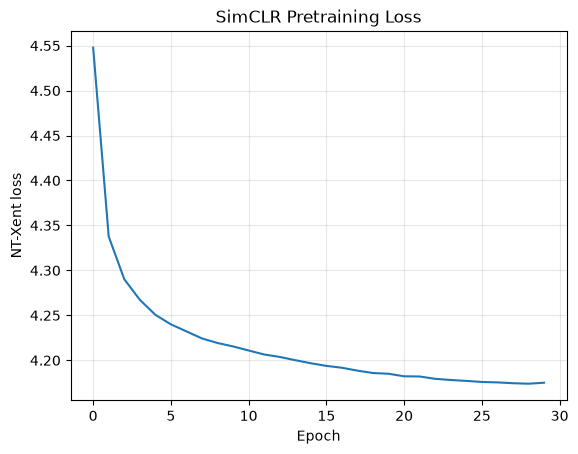

In [55]:
# --- Contrastive pretraining on KNOWN classes only, no labels used ---
# Uses mixed precision (AMP): faster and lighter on your GPU/laptop for the same work.

BATCH_SIZE = 512
EMBED_DIM = 128
PROJ_DIM = 64
EPOCHS = 50          # bumped from 30 -- loss hadn't plateaued yet
LR = 3e-4

train_contrastive_ds = ContrastiveIQDataset(X_train)
train_contrastive_loader = DataLoader(train_contrastive_ds, batch_size=BATCH_SIZE,
                                       shuffle=True, num_workers=4, drop_last=True,
                                       pin_memory=True, persistent_workers=True)

encoder = IQEncoder(embed_dim=EMBED_DIM).to(device)
proj_head = ProjectionHead(embed_dim=EMBED_DIM, proj_dim=PROJ_DIM).to(device)

optimizer = torch.optim.Adam(list(encoder.parameters()) + list(proj_head.parameters()), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

pretrain_losses = []
best_loss = float("inf")
patience, patience_counter = 8, 0

for epoch in range(EPOCHS):
    encoder.train(); proj_head.train()
    running_loss = 0.0
    for x1, x2 in train_contrastive_loader:
        x1, x2 = x1.to(device, non_blocking=True), x2.to(device, non_blocking=True)

        optimizer.zero_grad()
        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            z1 = proj_head(encoder(x1))
            z2 = proj_head(encoder(x2))
            loss = nt_xent_loss(z1, z2)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item()

    scheduler.step()
    avg_loss = running_loss / len(train_contrastive_loader)
    pretrain_losses.append(avg_loss)
    if epoch % 5 == 0 or epoch == EPOCHS - 1:
        print(f"Epoch {epoch+1}/{EPOCHS} | contrastive loss: {avg_loss:.4f}")

    if avg_loss < best_loss - 1e-4:
        best_loss = avg_loss
        patience_counter = 0
        best_encoder_state = {k: v.cpu().clone() for k, v in encoder.state_dict().items()}
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1} (loss plateaued)")
            break

encoder.load_state_dict(best_encoder_state)

import matplotlib.pyplot as plt
plt.plot(pretrain_losses)
plt.xlabel("Epoch"); plt.ylabel("NT-Xent loss"); plt.title("SimCLR Pretraining Loss")
plt.grid(alpha=0.3)
plt.show()

Linear probe closed-set accuracy: 0.40594574507617986


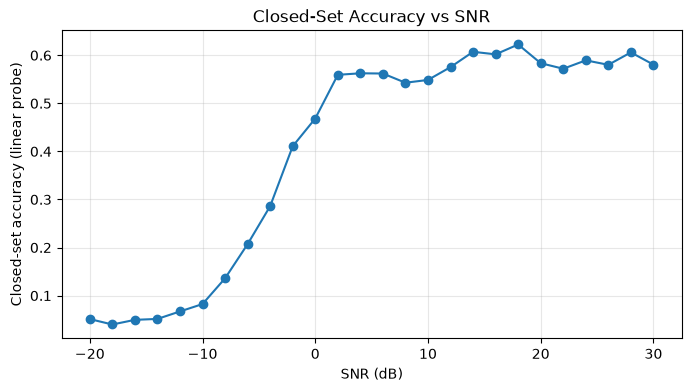

In [56]:
# --- Freeze encoder, extract embeddings, linear probe for closed-set accuracy ---

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

@torch.no_grad()
def get_embeddings(encoder, X, batch_size=512):
    encoder.eval()
    X_t = torch.from_numpy(X).float().permute(0, 2, 1)
    embs = []
    for i in range(0, len(X_t), batch_size):
        batch = X_t[i:i+batch_size].to(device)
        embs.append(encoder(batch).cpu().numpy())
    return np.concatenate(embs, axis=0)

emb_train = get_embeddings(encoder, X_train)
emb_val   = get_embeddings(encoder, X_val)
emb_test  = get_embeddings(encoder, X_test)
emb_unk   = get_embeddings(encoder, X_unk)

# linear probe -- secondary metric, not the headline
probe = LogisticRegression(max_iter=2000, random_state=SEED)
probe.fit(emb_train, y_train)
probe_pred = probe.predict(emb_test)

print("Linear probe closed-set accuracy:", accuracy_score(y_test, probe_pred))

# SNR-stratified closed-set accuracy
snr_bins = sorted(np.unique(snr_test))
closed_set_by_snr = []
for s in snr_bins:
    mask = snr_test == s
    acc = accuracy_score(y_test[mask], probe_pred[mask]) if mask.sum() > 0 else np.nan
    closed_set_by_snr.append(acc)

plt.figure(figsize=(8, 4))
plt.plot(snr_bins, closed_set_by_snr, marker="o")
plt.xlabel("SNR (dB)"); plt.ylabel("Closed-set accuracy (linear probe)")
plt.title("Closed-Set Accuracy vs SNR")
plt.grid(alpha=0.3)
plt.show()


In [58]:
# --- Open-set scoring, v2: Mahalanobis distance instead of raw Euclidean centroid distance ---

from sklearn.covariance import EmpiricalCovariance

class_means = {c: emb_train[y_train == c].mean(axis=0) for c in KNOWN_IDS}

centered = np.concatenate([emb_train[y_train == c] - class_means[c] for c in KNOWN_IDS], axis=0)
cov_estimator = EmpiricalCovariance().fit(centered)
precision = cov_estimator.precision_

def mahalanobis_score(embs, class_means, precision):
    dists = []
    for c, mu in class_means.items():
        diff = embs - mu
        d = np.einsum("ij,jk,ik->i", diff, precision, diff)
        dists.append(d)
    return np.stack(dists, axis=1).min(axis=1)

score_known_euclid = centroid_distance_score(emb_test, centroids)
score_unk_euclid = centroid_distance_score(emb_unk, centroids)
auroc_euclid = roc_auc_score(ood_labels, np.concatenate([score_known_euclid, score_unk_euclid]))
thr_euclid = np.percentile(score_known_euclid, 95)
fpr95_euclid = (score_unk_euclid <= thr_euclid).mean()

score_known_maha = mahalanobis_score(emb_test, class_means, precision)
score_unk_maha = mahalanobis_score(emb_unk, class_means, precision)
maha_scores = np.concatenate([score_known_maha, score_unk_maha])

auroc_maha = roc_auc_score(ood_labels, maha_scores)
thr_maha = np.percentile(score_known_maha, 95)
fpr95_maha = (score_unk_maha <= thr_maha).mean()

print(f"SSL Euclidean centroid   AUROC: {auroc_euclid:.4f} | FPR95: {fpr95_euclid:.4f}   (old method)")
print(f"SSL Mahalanobis distance AUROC: {auroc_maha:.4f} | FPR95: {fpr95_maha:.4f}   (new method)")

score_known, score_unk, auroc, fpr95 = score_known_maha, score_unk_maha, auroc_maha, fpr95_maha

Computing scores for known samples...
Computing scores for unknown samples...
Overall open-set AUROC (SSL centroid distance): 0.3735
FPR95 (unknowns wrongly accepted as known, at 95% known-acceptance threshold): 1.0000


[Supervised baseline] Epoch 1/15 | CE loss: 2.0802
[Supervised baseline] Epoch 6/15 | CE loss: 1.6298
[Supervised baseline] Epoch 11/15 | CE loss: 1.5349
[Supervised baseline] Epoch 15/15 | CE loss: 1.4879

Baseline (supervised MSP)  AUROC: 0.5676 | FPR95: 0.9519
SSL centroid distance      AUROC: 0.3735 | FPR95: 1.0000


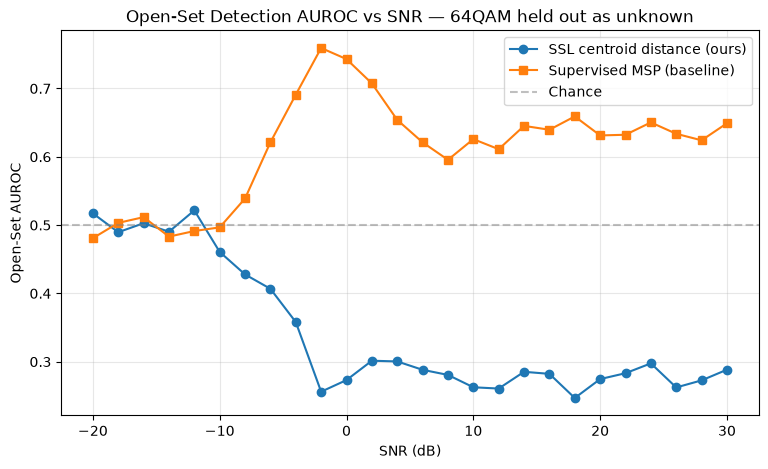


Open-set detection drops below AUROC 0.6 at SNR = -20 dB


In [65]:
# --- Real baseline to beat: max-softmax (MSP) open-set score on a SUPERVISED
#     embedding (same architecture, trained end-to-end with labels, no SSL).
#     This is the ablation your plan calls for: does SSL actually help open-set
#     rejection, or would a plain supervised classifier do just as well? ---
import torch.nn.functional as F
supervised_encoder = IQEncoder(embed_dim=EMBED_DIM).to(device)
classifier_head = nn.Linear(EMBED_DIM, len(KNOWN_IDS)).to(device)

sup_train_ds = LabeledIQDataset(X_train, np.searchsorted(np.array(KNOWN_IDS), y_train), snr_train)
sup_train_loader = DataLoader(sup_train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

sup_optimizer = torch.optim.Adam(
    list(supervised_encoder.parameters()) + list(classifier_head.parameters()), lr=LR
)
SUP_EPOCHS = 15

# FIXED: Print only at epochs 1, 6, 11 (i.e., epoch % 5 == 0 or last epoch)
for epoch in range(SUP_EPOCHS):
    supervised_encoder.train()
    classifier_head.train()
    running_loss = 0.0
    
    for xb, yb, _ in sup_train_loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = classifier_head(supervised_encoder(xb))
        loss = F.cross_entropy(logits, yb)
        sup_optimizer.zero_grad()
        loss.backward()
        sup_optimizer.step()
        running_loss += loss.item()
    
    # ONLY PRINT at epoch 1, 6, 11, and 15 (last)
    if epoch % 5 == 0 or epoch == SUP_EPOCHS - 1:
        print(f"[Supervised baseline] Epoch {epoch+1}/{SUP_EPOCHS} | CE loss: {running_loss/len(sup_train_loader):.4f}")

@torch.no_grad()
def get_msp_scores(X):
    supervised_encoder.eval()
    classifier_head.eval()
    X_t = torch.from_numpy(X).float().permute(0, 2, 1)
    scores = []
    for i in range(0, len(X_t), 512):
        batch = X_t[i:i+512].to(device)
        probs = F.softmax(classifier_head(supervised_encoder(batch)), dim=-1)
        # OOD score = 1 - max softmax prob (higher = more OOD-like, matches our convention)
        scores.append((1 - probs.max(dim=-1).values).cpu().numpy())
    return np.concatenate(scores)

msp_known = get_msp_scores(X_test)
msp_unk   = get_msp_scores(X_unk)
msp_scores = np.concatenate([msp_known, msp_unk])

msp_auroc = roc_auc_score(ood_labels, msp_scores)
msp_thr = np.percentile(msp_known, 95)
msp_fpr95 = (msp_unk <= msp_thr).mean()

print(f"\nBaseline (supervised MSP)  AUROC: {msp_auroc:.4f} | FPR95: {msp_fpr95:.4f}")
print(f"SSL centroid distance      AUROC: {auroc:.4f} | FPR95: {fpr95:.4f}")

# --- SNR-stratified comparison: this is the actual headline figure ---
def snr_stratified_auroc(score_known_arr, score_unk_arr, snr_known_arr, snr_unk_arr):
    bins = sorted(set(np.unique(snr_known_arr)) | set(np.unique(snr_unk_arr)))
    out = []
    for s in bins:
        sk = score_known_arr[snr_known_arr == s]
        su = score_unk_arr[snr_unk_arr == s]
        if len(sk) < 5 or len(su) < 5:
            out.append(np.nan)
            continue
        y = np.concatenate([np.zeros(len(sk)), np.ones(len(su))])
        sc = np.concatenate([sk, su])
        out.append(roc_auc_score(y, sc))
    return bins, out

bins, ssl_auroc_by_snr = snr_stratified_auroc(score_known, score_unk, snr_test, snr_unk)
_, msp_auroc_by_snr = snr_stratified_auroc(msp_known, msp_unk, snr_test, snr_unk)

plt.figure(figsize=(9, 5))
plt.plot(bins, ssl_auroc_by_snr, marker="o", label="SSL centroid distance (ours)")
plt.plot(bins, msp_auroc_by_snr, marker="s", label="Supervised MSP (baseline)")
plt.axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="Chance")
plt.xlabel("SNR (dB)")
plt.ylabel("Open-Set AUROC")
plt.title("Open-Set Detection AUROC vs SNR — 64QAM held out as unknown")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# find the SNR collapse point -- this is your failure-analysis figure
collapse_idx = next((i for i, a in enumerate(ssl_auroc_by_snr) if not np.isnan(a) and a < 0.6), None)
if collapse_idx is not None:
    print(f"\nOpen-set detection drops below AUROC 0.6 at SNR = {bins[collapse_idx]} dB")
else:
    print("\nNo SNR bin dropped below AUROC 0.6 -- check thresholds / sample sizes per bin.")

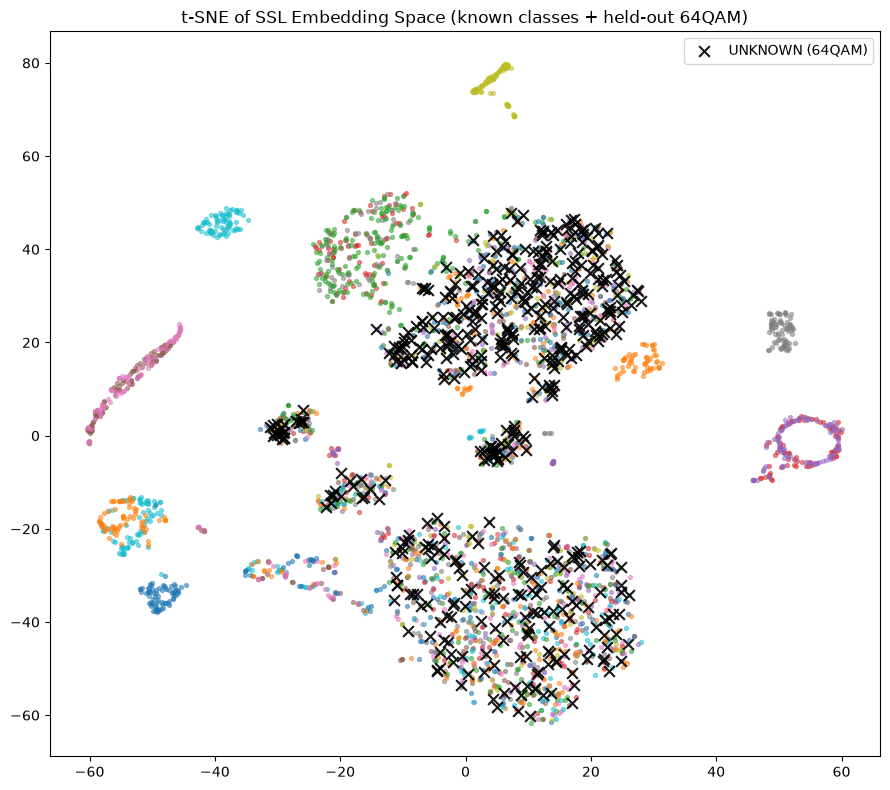

In [66]:
# --- t-SNE of SSL embedding space: known classes + the held-out unknown class ---
# (Use a subsample for speed -- t-SNE is O(n^2)-ish.)

from sklearn.manifold import TSNE

N_TSNE = 3000
rng = np.random.default_rng(SEED)

idx_known = rng.choice(len(emb_test), size=min(N_TSNE, len(emb_test)), replace=False)
idx_unk = rng.choice(len(emb_unk), size=min(500, len(emb_unk)), replace=False)

tsne_input = np.concatenate([emb_test[idx_known], emb_unk[idx_unk]], axis=0)
tsne_labels = np.concatenate([
    [CLASS_NAMES[c] for c in y_test[idx_known]],
    ["UNKNOWN (64QAM)"] * len(idx_unk)
])

tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, init="pca")
tsne_out = tsne.fit_transform(tsne_input)

plt.figure(figsize=(9, 8))
for lbl in np.unique(tsne_labels):
    mask = tsne_labels == lbl
    is_unknown = lbl.startswith("UNKNOWN")
    plt.scatter(tsne_out[mask, 0], tsne_out[mask, 1],
                s=60 if is_unknown else 8,
                marker="x" if is_unknown else "o",
                c="black" if is_unknown else None,
                alpha=0.9 if is_unknown else 0.5,
                label=lbl if is_unknown else None)
plt.title("t-SNE of SSL Embedding Space (known classes + held-out 64QAM)")
plt.legend()
plt.tight_layout()
plt.show()
